In [1]:
from random import sample
import json
import base64
import gzip
from io import BytesIO
import pandas as pd
import numpy as np
from PIL import Image
from tqdm.notebook import tqdm
from sqlalchemy import select, func
from eyened_orm import (
    Creator,
    ImageInstance,
    Modality,
    Feature,
    Annotation,
    AnnotationData,
    AnnotationType,
    Segmentation
)
from eyened_orm.db import Database
from eyened_orm.utils.attributes import df_to_attributes, print_import_summary

In [2]:
database = Database('../dev/eyened_dev.env')
session = database.create_session()

In [7]:
df = pd.read_csv('/mnt/oogergo/eyened/vasculature/releases/08_25/release_full.csv', index_col=0, nrows=20000)

In [8]:
df.head()

,bif_angles_arteries_mean,bif_angles_arteries_median,bif_angles_veins_mean,bif_angles_veins_median,bif_arteries,bif_veins,coverage_vessels,cre_arteries,cre_veins,diam_arteries_median,...,tort_vessels_infl_arteries,tort_vessels_infl_veins,tort_vessels_skl_arteries,tort_vessels_skl_veins,tort_vessels_spl_arteries,tort_vessels_spl_veins,vd_arteries,vd_total_arteries,vd_total_veins,vd_veins
193024,81.556199,86.443819,84.580285,84.796144,21.0,22.0,0.038545,10.891064,15.698664,4.046173,...,2.0,2.0,1.094359,1.090123,1.032671,1.027740,0.054681,0.049093,0.048473,0.064103
193027,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
193032,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
193035,NaN,NaN,83.103916,83.103916,0.0,1.0,0.378599,NaN,2.288663,5.446048,...,1.0,0.0,1.158825,1.056768,1.095385,1.011553,NaN,0.000483,0.001393,NaN
193038,80.726368,82.539068,80.016493,81.128589,23.0,27.0,0.035730,10.605799,15.280858,3.234918,...,1.5,2.0,1.088264,1.085257,1.021992,1.031694,0.056898,0.048109,0.050957,0.061723


<Axes: >

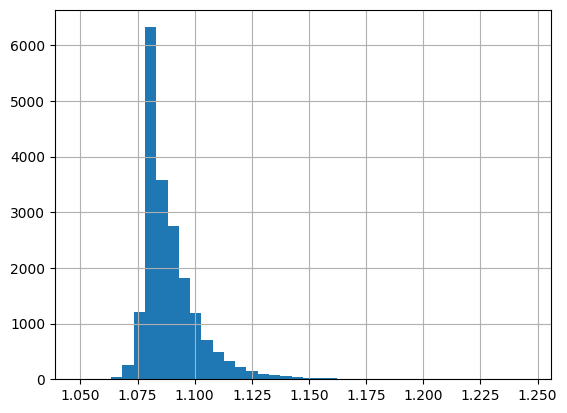

In [9]:
df['tort_vessels_skl_arteries'].hist(bins=40)

In [10]:
# df should have image IDs in its index and attributes as columns
image_attributes = df_to_attributes(session, df, model_name="VascX", version="0.1")

# Optional: print summary of what was imported
attributes = [ia.Attribute for ia in image_attributes if ia.Attribute is not None]
print_import_summary(attributes, image_attributes)

Existing Attributes:
  - bif_angles_arteries_mean: 0 new, 95 updated
  - bif_angles_arteries_median: 0 new, 90 updated
  - bif_angles_veins_mean: 0 new, 96 updated
  - bif_angles_veins_median: 0 new, 91 updated
  - bif_arteries: 0 new, 0 updated
  - bif_veins: 0 new, 0 updated
  - coverage_vessels: 0 new, 96 updated
  - cre_arteries: 0 new, 95 updated
  - cre_veins: 0 new, 96 updated
  - diam_arteries_median: 0 new, 95 updated
  - diam_arteries_std: 0 new, 95 updated
  - diam_veins_median: 0 new, 95 updated
  - diam_veins_std: 0 new, 96 updated
  - lapl_image: 0 new, 96 updated
  - norm_tort_segments_curv_arteries: 0 new, 96 updated
  - norm_tort_segments_curv_veins: 0 new, 96 updated
  - norm_tort_segments_infl_arteries: 0 new, 95 updated
  - norm_tort_segments_infl_veins: 0 new, 96 updated
  - norm_tort_segments_skl_arteries: 0 new, 96 updated
  - norm_tort_segments_skl_veins: 0 new, 96 updated
  - norm_tort_segments_spl_arteries: 0 new, 96 updated
  - norm_tort_segments_spl_veins: 0

In [11]:
len(df)

20000

In [13]:
len(image_attributes)

885514

In [14]:
for attribute in image_attributes:
    session.add(attribute)
# # Don't forget to commit the transaction
session.commit()

IntegrityError: (pymysql.err.IntegrityError) (1452, 'Cannot add or update a child row: a foreign key constraint fails (`eyened_database`.`ImageAttributes`, CONSTRAINT `ImageAttributes_ibfk_2` FOREIGN KEY (`ImageInstanceID`) REFERENCES `ImageInstance` (`ImageInstanceID`) ON DELETE CASCADE)')
[SQL: INSERT INTO `ImageAttributes` (`ImageInstanceID`, `AttributeID`, `ValueFloat`, `ValueInt`, `ValueText`, `ValueJSON`) VALUES (%(ImageInstanceID)s, %(AttributeID)s, %(ValueFloat)s, %(ValueInt)s, %(ValueText)s, %(ValueJSON)s)]
[parameters: {'ImageInstanceID': 212414, 'AttributeID': 1, 'ValueFloat': 96.50145805530238, 'ValueInt': None, 'ValueText': None, 'ValueJSON': 'null'}]
(Background on this error at: https://sqlalche.me/e/20/gkpj)